In [ ]:
from google.colab import files
uploaded = files.upload()

Saving emails.csv to emails.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("emails.csv")
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [ ]:
print(df.columns)

Index(['text', 'spam'], dtype='object')


In [ ]:
# Rename columns automatically based on common patterns

if 'text' in df.columns:
    df.rename(columns={'text': 'email'}, inplace=True)
elif 'message' in df.columns:
    df.rename(columns={'message': 'email'}, inplace=True)

if 'label' not in df.columns:
    for col in df.columns:
        if 'spam' in col.lower() or 'label' in col.lower():
            df.rename(columns={col: 'label'}, inplace=True)

print(df.columns)

Index(['email', 'label'], dtype='object')


In [ ]:
df['label'] = df['label'].astype(str).str.strip().str.lower()

# Handle multiple formats
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1,
    '0': 0,
    '1': 1
})

# Drop bad rows
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

print(df['label'].value_counts())

label
0    4360
1    1368
Name: count, dtype: int64


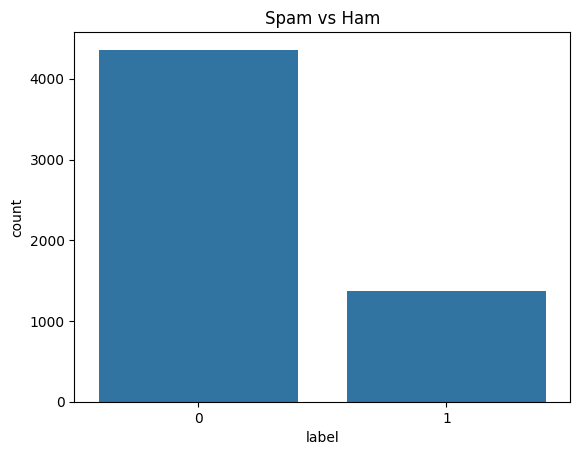

In [ ]:
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham")
plt.show()

In [ ]:
nltk.download('stopwords')

def preprocess(text):
    text = str(text).lower()
    text = re.sub('[^a-z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stopwords.words('english')]
    return ' '.join(words)

df['clean_email'] = df['email'].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_email']).toarray()
y = df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naïve Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naïve Bayes Accuracy: 0.9781849912739965


In [ ]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.9790575916230366


In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       856
           1       0.99      0.93      0.96       290

    accuracy                           0.98      1146
   macro avg       0.98      0.96      0.97      1146
weighted avg       0.98      0.98      0.98      1146



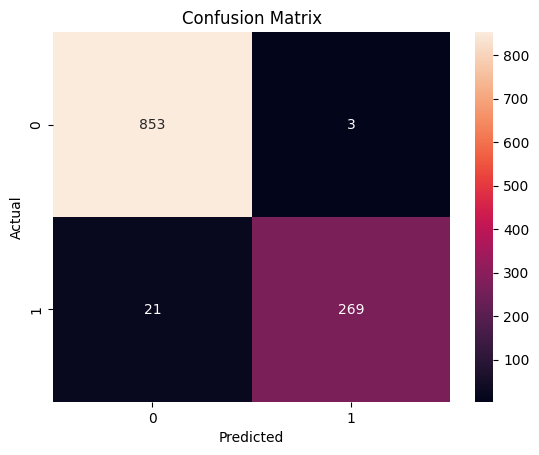

In [ ]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [24]:
sample = ["Get 200k for free"]

sample_clean = [preprocess(sample[0])]
sample_vector = vectorizer.transform(sample_clean)

prediction = lr_model.predict(sample_vector)

print("Spam" if prediction[0] == 1 else "Not Spam")

Spam


In [ ]:
import pickle

pickle.dump(lr_model, open('model.pkl', 'wb'))
pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))